# **DIDP model**

In [1]:
%%writefile CVRPTW_DIDP_model_declaration.py
import sys
import os
import numpy as np
import vrplib
import modified_didppy as m_dp


current_num_locations = 0
current_num_vehicles = 0
current_capacity = 0.0
current_cust_demand = []
current_avail_time = []
current_due_date = []
current_serve_time = []
current_travel_cost = []

def read_formated_data(file_path):
    """
    Reads a Solomon format .txt file using vrplib and returns a dictionary 
    formatted for CVRPTW LP Relaxation and DIDP models.
    
    Ensures all numerical data (demand, time windows, service times, costs, capacity) 
    are returned as floats.
    """
    # 1. Read instance using vrplib
    # instance_format='solomon' ensures correct parsing of sections
    instance = vrplib.read_instance(file_path, instance_format='solomon')

    # 2. Extract Data & Cast to Float
    # 'edge_weight' is the distance matrix computed by vrplib
    travel_cost = instance['edge_weight'].astype(float).tolist()
    
    # 'node_coord' is available if you ever need it, but we use the pre-calc weights
    num_locations = len(instance['node_coord'])

    # 3. Return Bundle
    return {
        'num_locations': num_locations,
        'num_vehicles': int(instance.get('vehicles', 25)), 
        'capacity': float(instance['capacity']),
        
        # Cast demand to float list
        'demand': instance['demand'].astype(float).tolist(),
        
        # Cast Time Windows to float list
        # Col 0 is ready_time (earliest arrival), Col 1 is due_date (latest arrival)
        'ready_time': instance['time_window'][:, 0].astype(float).tolist(),
        'due_date': instance['time_window'][:, 1].astype(float).tolist(),
        
        # Cast Service Time to float list
        'service_time': instance['service_time'].astype(float).tolist(),
        
        # Use the pre-computed edge weights from vrplib
        'travel_cost': travel_cost
    }

def update_globals_for_cvrptw(file_path):
    """Updates global variables from file."""
    global current_num_locations, current_num_vehicles, current_capacity
    global current_cust_demand, current_avail_time, current_due_date
    global current_serve_time, current_travel_cost
    
    data = read_formated_data(file_path)
    
    current_num_locations = data['num_locations']
    current_num_vehicles = data['num_vehicles']
    current_capacity = data['capacity']
    current_cust_demand = data['demand']
    current_serve_time = data['service_time']
    current_travel_cost = data['travel_cost']
    
    # Split Time Windows into Ready and Due lists
    current_avail_time = data['ready_time']
    current_due_date = data['due_date']
    
    return True

def creation_of_didp_model_function():
    num_locations = current_num_locations
    num_vehicles = current_num_vehicles
    q = current_capacity
    cust_demand = current_cust_demand
    avail_time = current_avail_time
    due_date = current_due_date
    serve_time = current_serve_time
    travel_cost = current_travel_cost
    
    # =====================================================================================
    # DIDP Model Definition
    # =====================================================================================
    model = m_dp.Model(float_cost=True)

    # Object types for customers/locations and vehicles
    customer = model.add_object_type(number=num_locations)
    vehicle = model.add_object_type(number=num_vehicles)

    # -------------------- State Variables --------------------
    # Set of unvisited customers
    unvisited_locations = model.add_set_var(object_type=customer, target=list(range(1, num_locations)))

    # Per-vehicle state variables, stored in Python lists for easy access
    vehicle_locations = [
    model.add_element_var(object_type=customer, target=0, name=f"loc_v{v}")
    for v in range(num_vehicles)
    ]
    vehicle_loads = [
    model.add_float_var(target=0, name=f"load_v{v}")
    for v in range(num_vehicles)
    ]
    vehicle_times = [
    model.add_float_resource_var(target=0, less_is_better=True, name=f"time_v{v}")
    for v in range(num_vehicles)
    ]
    chosen_customer = model.add_element_var(object_type=customer, target=0, name="chosen_customer")
    alpha = model.add_int_var(target=0, name="alpha")

    # -------------------- Tables of Constants --------------------
    demand = model.add_float_table(cust_demand)
    ready_time = model.add_float_table(avail_time)
    due_time = model.add_float_table(due_date)
    service_time = model.add_float_table(serve_time)
    travel_time = model.add_float_table(travel_cost)

    # -------------------- Transitions --------------------
    # Choose customer j to be visited next
    for j in range(1, num_locations):
        choosing_customer_transition = m_dp.Transition(
            name=f"choose_customer_{j}_to_visit",
            cost=m_dp.FloatExpr.state_cost(),
            preconditions =[
                unvisited_locations.contains(j),
                alpha == 0
                ],
            effects=[
                (chosen_customer, j),
                (alpha, 1)
                ],
        )
        model.add_transition(choosing_customer_transition)

        # Transition to visit a customer j with a vehicle v
    for v in range(num_vehicles):
        arrival_time = m_dp.max(
            vehicle_times[v] + travel_time[vehicle_locations[v], chosen_customer],
            ready_time[chosen_customer]
        )

        departure_time = arrival_time + service_time[chosen_customer]

        visit_transition = m_dp.Transition(
            name=f"visit_chosen_customer_with_vehicle_{v}",
            cost=travel_time[vehicle_locations[v], chosen_customer] + m_dp.FloatExpr.state_cost(),
            preconditions=[
                unvisited_locations.contains(chosen_customer),
                vehicle_loads[v] + demand[chosen_customer] <= q,
                arrival_time <= due_time[chosen_customer],
                alpha == 1,
            ],
            effects=[
                (unvisited_locations, unvisited_locations.remove(chosen_customer)),
                (vehicle_locations[v], chosen_customer),
                (vehicle_loads[v], vehicle_loads[v] + demand[chosen_customer]),
                (vehicle_times[v], departure_time),
                (alpha, 0),
            ],
        )

        model.add_transition(visit_transition)

    # Transitions for each vehicle to return to the depot after all customers are served
    for v in range(num_vehicles):
        return_to_depot_transition = m_dp.Transition(
            name=f"return_vehicle_{v}_to_depot",
            cost=travel_time[vehicle_locations[v], 0] + m_dp.FloatExpr.state_cost(),
            preconditions=[unvisited_locations.is_empty(), vehicle_locations[v] != 0],
            effects=[(vehicle_locations[v], 0)],
        )
        model.add_transition(return_to_depot_transition)

    # --- 1. Global Capacity Constraint (The Efficient "Cut") ---
    # Logic: Total Capacity Available >= Total Demand Remaining
    # Summing variables in Python creates a DIDP expression automatically
    total_current_load = sum(vehicle_loads) 
    total_fleet_capacity = num_vehicles * q
    
    # demand[unvisited_locations] automatically sums the weight of items in the set
    model.add_state_constr(
        (total_fleet_capacity - total_current_load) >= demand[unvisited_locations]
    )
    
    # -------------------- Base Case --------------------
    # All customers visited AND all vehicles are at the depot
    base_conditions = [unvisited_locations.is_empty()]
    for v in range(num_vehicles):
        base_conditions.append(vehicle_locations[v] == 0)
    model.add_base_case(base_conditions)

    # =========================================================
    # Dual Bounds
    # =========================================================

    # --- Pre-computation of Min Edge Tables ---
    # min_from[i]: The cheapest cost to LEAVE node i
    min_from_val = [min(travel_cost[i][k] for k in range(num_locations) if k != i) for i in range(num_locations)]
    min_from = model.add_float_table(min_from_val)

    # min_to[j]: The cheapest cost to ENTER node j
    min_to_val = [min(travel_cost[k][j] for k in range(num_locations) if k != j) for j in range(num_locations)]
    min_to = model.add_float_table(min_to_val)

    # --- Dual Bound 1: Minimum Outgoing Edges ---
    # Logic: 
    # 1. We must leave every customer that is currently unvisited.
    # 2. Every vehicle that is currently NOT at the depot must leave its current location.
    lb_outgoing = min_from[unvisited_locations]  # Sum of min_from for all unvisited nodes
    for v in range(num_vehicles):
        # If vehicle v is at a customer (location != 0), it must leave that customer eventually.
        # We add the min cost to leave its current location.
        lb_outgoing += (vehicle_locations[v] != 0).if_then_else(min_from[vehicle_locations[v]], 0.0)
    model.add_dual_bound(lb_outgoing)
    
    # --- Dual Bound 2: Minimum Incoming Edges ---
    # Logic:
    # 1. We must enter every customer that is currently unvisited.
    # 2. Every vehicle that is currently NOT at the depot must eventually return (enter) the depot.
    lb_incoming = min_to[unvisited_locations] # Sum of min_to for all unvisited nodes
    for v in range(num_vehicles):
        # If vehicle v is out working (location != 0), it must return to depot (enter node 0).
        lb_incoming += (vehicle_locations[v] != 0).if_then_else(min_to[0], 0.0)
    model.add_dual_bound(lb_incoming)

    # =========================================================
    # 3. Bundle Metadata
    # =========================================================
    metadata = {
        "unvisited_locations": unvisited_locations,
        "vehicle_locations": vehicle_locations,
        "vehicle_loads": vehicle_loads,
        "vehicle_times": vehicle_times,
        "distance_matrix": travel_cost,
        "demand": cust_demand,
        "due_time": due_date,
        "ready_time": avail_time,
        "service_time": serve_time,
        "capacity": q,
        "num_vehicles": num_vehicles,
        "num_locations": num_locations
    }
    
    didp_bundle = (model, metadata)
    return didp_bundle

Writing CVRPTW_DIDP_model_declaration.py


# **Worker**

In [2]:
%%writefile worker_CVRPTW_profiling.py
import sys
import os
import json
import time
import threading
import psutil
import modified_didppy as m_dp

# --- CONFIGURATION ---
MEMORY_LIMIT_MB = 12000 

# --- 1. SETUP PATHS ---
PROJECT_ROOT = r"C:\Users\ACER\Desktop\Code\0_Thesis_implementation\2_DIDP_custom_search_guidance_local\Thesis_modified_DIDP"
sys.path.append(os.getcwd()) 
if PROJECT_ROOT not in sys.path: sys.path.append(PROJECT_ROOT)

# --- 2. IMPORTS ---
try:
    import CVRPTW_DIDP_model_declaration as domain
except ImportError as e:
    print(json.dumps({"status": "error", "message": f"Import Error: {e}"}))
    sys.exit(1)

# --- 3. MEMORY GUARD ---
def memory_guard():
    process = psutil.Process(os.getpid())
    limit_bytes = MEMORY_LIMIT_MB * 1024 * 1024
    while True:
        try:
            if process.memory_info().rss > limit_bytes:
                os._exit(1) # Hard exit to avoid swap death
            time.sleep(1)
        except: break

# --- 4. MAIN SOLVER LOGIC ---
if __name__ == "__main__":
    try:
        # Start Memory Guard
        threading.Thread(target=memory_guard, daemon=True).start()

        if len(sys.argv) < 5: 
            raise ValueError("Args mismatch. Usage: worker.py <instance> <data_dir> <time_limit> <node_limit>")
        
        instance_name = sys.argv[1]
        data_dir = sys.argv[2]
        time_limit = float(sys.argv[3])
        node_limit = int(sys.argv[4])

        file_path = os.path.join(data_dir, instance_name)
        
        # 1. Load Instance
        if not domain.update_globals_for_cvrptw(file_path):
            raise ValueError(f"Failed to load: {file_path}")

        # 2. Setup Model (No Compilation needed, standard CABS)
        didp_bundle = domain.creation_of_didp_model_function() 
        model, metadata = didp_bundle
        
        # 3. Instantiate Solver (Standard CABS)
        # We use normal CABS because we are benchmarking the single dual bound defined in the model
        solver = m_dp.CABS(
            model,
            time_limit=time_limit,
            initial_beam_size=1,       
            max_beam_size=None,        
            quiet=False, # CRITICAL: Enable logs for parsing
        )
        
        start_time = time.time()
        
        # 4. Run Search (FAST C++ LOOP)
        # Passing node_limit enables profiling behavior
        solution = solver.search()
        
        duration = time.time() - start_time
        
        # 5. Output (History is in stdout logs)
        output = {
            "status": "success",
            "cost": solution.cost,
            "expanded": solution.expanded,
            "generated": solution.generated,
            "duration": duration,
            "is_optimal": solution.is_optimal,
            "history": [] # Manager parses this from stdout
        }
        print("\n" + json.dumps(output))

    except Exception as e:
        print("\n" + json.dumps({"status": "error", "message": str(e)}))
        sys.exit(1)

Writing worker_CVRPTW_profiling.py


# **Manager**

In [6]:
import subprocess
import pandas as pd
import numpy as np
import os
import sys
import json
import matplotlib.pyplot as plt

# ==========================================
# CONFIGURATION
# ==========================================
NODE_EXPANSION_LIMIT = 100_000 
SOLVER_TIME_LIMIT = 900 

# Dataset Directories
DATA_DIRS = [
    r"C:\Users\ACER\Desktop\Code\0_Thesis_implementation\2_DIDP_custom_search_guidance_local\Thesis_modified_DIDP\4_CVRPTW_dual_bounds_and_models\Datasets\homberger_200_customer_instances",
    r"C:\Users\ACER\Desktop\Code\0_Thesis_implementation\2_DIDP_custom_search_guidance_local\Thesis_modified_DIDP\4_CVRPTW_dual_bounds_and_models\Datasets\Solomon"
]

# CSV File containing list of instances to run
TARGET_LIST_CSV = "CVRPTW_single_dual_bound_selected_results_1800s_lim.csv"

# Output for Profiling Logs
OUTPUT_FOLDER = "CVRPTW_single_dual_bound_Profiling_Results"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

def find_file_in_dirs(filename, directories):
    """Searches for a file (with or without extension) in a list of directories."""
    for folder in directories:
        if not os.path.exists(folder): continue
        
        # Check exact path
        full_path = os.path.join(folder, filename)
        if os.path.exists(full_path): return full_path, folder
        
        # Check with .txt appended
        if os.path.exists(full_path + ".txt"): return full_path + ".txt", folder
        
        # Check just filename (maybe CSV has path but dir doesn't match)
        base = os.path.basename(filename)
        full_path_base = os.path.join(folder, base)
        if os.path.exists(full_path_base): return full_path_base, folder
        if os.path.exists(full_path_base + ".txt"): return full_path_base + ".txt", folder
        
    return None, None

def run_profiling():
    print(f"🔹 Starting CVRPTW Profiling (Max Nodes: {NODE_EXPANSION_LIMIT})...")
    
    if not os.path.exists(TARGET_LIST_CSV):
        print(f"❌ Target list CSV missing: {TARGET_LIST_CSV}")
        return
        
    try:
        df_targets = pd.read_csv(TARGET_LIST_CSV)
        # Assuming column is 'Instance' based on typical structure
        target_instances = df_targets['Instance'].tolist()
        print(f"   📋 Loaded {len(target_instances)} instances to profile from CSV.")
    except Exception as e:
        print(f"❌ Error reading target CSV: {e}")
        return

    # Process Only Listed Instances
    for i, instance_name in enumerate(target_instances):
        instance_name = str(instance_name).strip()
        safe_name = instance_name.replace(".txt", "")
        output_txt_path = os.path.join(OUTPUT_FOLDER, f"solver_log_{safe_name}.txt")
        
        if os.path.exists(output_txt_path) and os.path.getsize(output_txt_path) > 100:
            print(f"[{i+1}/{len(target_instances)}] Skipping {instance_name} (Log exists).")
            continue 

        # Find where this file lives
        file_path, found_dir = find_file_in_dirs(instance_name, DATA_DIRS)
        
        if not file_path:
            print(f"⚠️  Instance file not found in any DATA_DIR: {instance_name}")
            continue

        print(f"\n[{i+1}/{len(target_instances)}] Profiling {instance_name}...")
        
        # Run Worker (pass just filename and dir separately)
        filename_only = os.path.basename(file_path)
        cmd = [
            sys.executable, "-u", "worker_CVRPTW_profiling.py",
            filename_only, found_dir, str(SOLVER_TIME_LIMIT), str(NODE_EXPANSION_LIMIT)
        ]
        
        try:
            result = subprocess.run(cmd, capture_output=True, text=True)
            
            with open(output_txt_path, "w", encoding="utf-8") as f:
                f.write(f"Instance: {instance_name}\n")
                f.write("="*40 + "\n\n")
                f.write(result.stdout)
                if result.stderr:
                    f.write("\n\n=== STDERR ===\n")
                    f.write(result.stderr)
            
            if result.returncode != 0:
                print(f"   ⚠️ Worker Failed. Log saved.")
            else:
                print(f"   ✅ Finished.")
            
        except Exception as e:
            print(f"   ❌ Error executing worker: {e}")

if __name__ == "__main__":
    run_profiling()

🔹 Starting CVRPTW Profiling (Max Nodes: 100000)...
   📋 Loaded 10 instances to profile from CSV.

[1/10] Profiling C104.txt...
   ✅ Finished.

[2/10] Profiling C201.txt...
   ✅ Finished.

[3/10] Profiling R104.txt...
   ✅ Finished.

[4/10] Profiling R203.txt...
   ✅ Finished.

[5/10] Profiling RC104.txt...
   ✅ Finished.

[6/10] Profiling C1_2_10.TXT...
   ✅ Finished.

[7/10] Profiling C2_2_10.TXT...
   ✅ Finished.

[8/10] Profiling R1_2_10.TXT...
   ✅ Finished.

[9/10] Profiling R2_2_10.TXT...
   ✅ Finished.

[10/10] Profiling RC2_2_10.TXT...
   ✅ Finished.


# **Data collection**

🔹 Processing CVRPTW Logs (Plot Limit: 100000)...
   Found 10 log files.

📊 Aggregating Results...
   ✅ Saved aggregated data to CVRPTW_single_dual_bound_Profiles_Parsed\CVRPTW_single_dual_bound_Average_gaps_vs_Expansion_limit.csv


C:\Users\ACER\AppData\Local\Temp\ipykernel_22700\3778203509.py:156: RuntimeWarning: Mean of empty slice
  mean_gaps = np.nanmean(gap_matrix, axis=0)


   ✅ Saved plot to CVRPTW_single_dual_bound_Profiles_Parsed


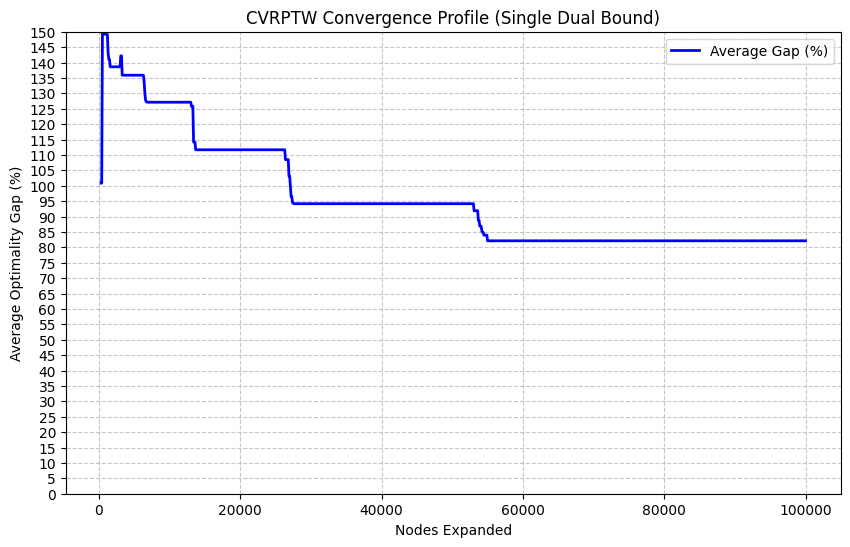

In [7]:
import pandas as pd
import numpy as np
import os
import re
import glob
import math
import matplotlib.pyplot as plt

# ==========================================
# CONFIGURATION
# ==========================================
LOG_DIR = "CVRPTW_single_dual_bound_Profiling_Results"
OUTPUT_PROFILE_DIR = "CVRPTW_single_dual_bound_Profiles_Parsed"
os.makedirs(OUTPUT_PROFILE_DIR, exist_ok=True)

REF_RESULTS_CSV = "CVRPTW_single_dual_bound_selected_results_1800s_lim.csv" 
NODE_EXPANSION_LIMIT = 100_000 
SAMPLE_STEP = 100 

# ==========================================
# HELPER FUNCTIONS
# ==========================================
def parse_solver_log(file_path):
    raw_history = []
    current_best_cost = float('inf')
    
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                match_primal = re.search(r"New primal bound:\s*([0-9\.\+\-eE]+),\s*expanded:\s*(\d+)", line)
                if match_primal:
                    cost = float(match_primal.group(1))
                    expanded = int(match_primal.group(2))
                    current_best_cost = cost
                    raw_history.append((expanded, cost))
                    if expanded > NODE_EXPANSION_LIMIT: break
                    continue

                match_beam = re.search(r"Searched with beam size:.*expanded:\s*(\d+)", line)
                if match_beam:
                    expanded = int(match_beam.group(1))
                    raw_history.append((expanded, current_best_cost))
                    if expanded > NODE_EXPANSION_LIMIT: break
                        
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
    
    # Sort and Clean History (Keep BEST cost for duplicate steps)
    raw_history.sort(key=lambda x: x[0])
    cleaned_history = []
    for expanded, cost in raw_history:
        if not cleaned_history:
            cleaned_history.append((expanded, cost))
        else:
            last_expanded, last_cost = cleaned_history[-1]
            if expanded == last_expanded:
                cleaned_history[-1] = (expanded, min(cost, last_cost))
            else:
                cleaned_history.append((expanded, cost))
                
    return cleaned_history

def calculate_dense_gaps(history, optimal_cost, limit):
    max_steps = limit // SAMPLE_STEP
    dense_gaps = np.full(max_steps, np.nan)

    if not history: return dense_gaps

    current_cost = float('inf')
    hist_idx = 0
    max_nodes_reached = history[-1][0]
    
    for i in range(max_steps):
        current_node_count = (i + 1) * SAMPLE_STEP
        
        # CUTOFF LOGIC
        if current_node_count > max_nodes_reached:
            break
        
        while hist_idx < len(history) and history[hist_idx][0] <= current_node_count:
            val = history[hist_idx][1]
            if val < current_cost:
                current_cost = val
            hist_idx += 1
            
        if current_cost == float('inf'):
            dense_gaps[i] = np.nan 
        else:
            denom = optimal_cost if optimal_cost > 0 else 1.0
            gap = (current_cost - optimal_cost) / denom * 100.0
            if gap < 0: gap = 0.0 
            dense_gaps[i] = gap
        
    return dense_gaps

def process_results():
    print(f"🔹 Processing CVRPTW Logs (Plot Limit: {NODE_EXPANSION_LIMIT})...")
    
    if not os.path.exists(REF_RESULTS_CSV):
        print(f"❌ Reference CSV missing: {REF_RESULTS_CSV}")
        return
    
    df_ref = pd.read_csv(REF_RESULTS_CSV)
    
    # Cost Column Detection
    cost_col = 'Best Known Cost' if 'Best Known Cost' in df_ref.columns else 'Cost'
    
    # Improved Matching Map: Store simple filename -> cost
    bks_map = {}
    for _, row in df_ref.iterrows():
        raw_name = str(row['Instance']).strip()
        # Clean: "C101.txt" -> "C101", "R1_2_1.txt" -> "R1_2_1"
        clean_key = raw_name.replace(".txt", "").replace(".vrp", "")
        bks_map[clean_key] = float(row[cost_col])

    log_files = glob.glob(os.path.join(LOG_DIR, "solver_log_*.txt"))
    print(f"   Found {len(log_files)} log files.")
    
    all_dense_gaps = []

    for log_path in log_files:
        filename = os.path.basename(log_path)
        # Log name: "solver_log_C101.txt" -> "C101"
        name_clean = filename.replace("solver_log_", "").replace(".txt", "").strip()
        
        # Fuzzy Match Logic
        opt_cost = None
        if name_clean in bks_map:
            opt_cost = bks_map[name_clean]
        else:
            # Try to find if name_clean is inside a key or vice versa (e.g. C1_2_1 vs C1_2_10)
            for k in bks_map:
                if k == name_clean: 
                    opt_cost = bks_map[k]; break
            if opt_cost is None:
                # print(f"Skipping {name_clean}")
                continue

        history = parse_solver_log(log_path)
        if history:
            dense_gaps = calculate_dense_gaps(history, opt_cost, NODE_EXPANSION_LIMIT)
            all_dense_gaps.append(dense_gaps)
            
            df_hist = pd.DataFrame({
                'Node_Count': np.arange(SAMPLE_STEP, NODE_EXPANSION_LIMIT + 1, SAMPLE_STEP),
                'Gap_Percent': dense_gaps
            })
            df_hist.to_csv(os.path.join(OUTPUT_PROFILE_DIR, f"gap_profile_{name_clean}.csv"), index=False)

    if all_dense_gaps:
        print("\n📊 Aggregating Results...")
        gap_matrix = np.vstack(all_dense_gaps)
        
        with np.errstate(invalid='ignore'):
            mean_gaps = np.nanmean(gap_matrix, axis=0)
        
        x_axis = np.arange(SAMPLE_STEP, NODE_EXPANSION_LIMIT + 1, SAMPLE_STEP)
        
        df_agg = pd.DataFrame({
            'Node_Count': x_axis,
            'Average_Gap_Percent': mean_gaps
        })
        
        agg_path = os.path.join(OUTPUT_PROFILE_DIR, "CVRPTW_single_dual_bound_Average_gaps_vs_Expansion_limit.csv")
        df_agg.to_csv(agg_path, index=False)
        print(f"   ✅ Saved aggregated data to {agg_path}")
        
        plt.figure(figsize=(10, 6))
        
        valid_mask = ~np.isnan(mean_gaps)
        if np.any(valid_mask):
            plt.plot(x_axis[valid_mask], mean_gaps[valid_mask], label='Average Gap (%)', color='blue', linewidth=2)
            
            max_y = np.max(mean_gaps[valid_mask])
            upper_limit = math.ceil(max_y / 5) * 5
            
            plt.yticks(np.arange(0, upper_limit + 5, 5))
            plt.ylim(0, upper_limit)
        else:
            print("⚠️ No valid data points to plot.")

        plt.xlabel('Nodes Expanded')
        plt.ylabel('Average Optimality Gap (%)')
        plt.title('CVRPTW Convergence Profile (Single Dual Bound)')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.legend()
        
        plot_path = os.path.join(OUTPUT_PROFILE_DIR, "convergence_plot.png")
        plt.savefig(plot_path)
        print(f"   ✅ Saved plot to {OUTPUT_PROFILE_DIR}")
        plt.show()
    else:
        print("\n⚠️ No valid data extracted.")

if __name__ == "__main__":
    process_results()